## Formatting for Plots
### (IGNORE THIS IF YOU ARE A GENERAL USER)

In [34]:
import sys
import pandas as pd
from pathlib import Path
root = Path().resolve()
src_path = root / "src"
if str(src_path) not in sys.path:
    sys.path.append(str(src_path))

from analysislib import formatting
from analysislib import graphs
formatting.format_notebook()

from analysislib import sdss
sdss.setup(pd.read_csv("data/SDSS_500k_v7.csv"))

---

## Part 5 — Machine Learning and Galaxy Evolution

---

<div style="width: 1200px">

Over the past four notebooks, we have built up a rich physical picture of galaxy evolution through observations and analysis of the SDSS. We know that galaxies cluster into two colour populations, that their structure correlates with their evolutionary state, and that the most massive galaxies are almost universally quenched. We have computed physical distances and sizes, and traced how these properties vary across cosmic time.

However, all of this analysis has been *descriptive*. In this notebook, we'll combine all of the stuff we've learnt and make the next step of teaching a computer to make predictions, and use those predictions to directly answer the second part of our central question: *"What are the features galaxy transformation, and **can we predict where a galaxy is in its evolutionary lifecycle?**"*

We'll tackle two distinct tasks:

1. **Predicting redshift from colours**: a supervised regression problem with real astronomical applications, using only photometric colours to estimate a galaxy's distance
2. **Positioning galaxies in an evolutionary lifecycle**: an unsupervised discovery problem, asking the computer to find the natural structure in galaxy data without being told what to look for

These two tasks were chosen to show that machine learning can both extract physical information (distance) from data we already have, as well as discover physical structure (evolutionary stage) that we did not impose.

Let's begin!

</div>

---

### What is Machine Learning?

---

<div style="width: 1200px">

In traditional programming, we humans writes explicit rules that a computer follows. For example, your washing machine was coded so that when you press the start button, the tub starts spinning, and depending on which setting you chose, it might stop after 20 minutes, half an hour, 1 hour, etc. The point is that someone hard-coded that logic into your washing machine.

On the other hand, machine learning works a bit differently: **instead of writing the rules, we show the computer examples and let it find the rules itself**. For example, we could give it thousands of galaxies where we already know the redshift value, and the model tries to learn the patterns that connect the measurements to the redshift. Then, we ask it to apply those patterns to predict the redshift of new galaxies it hasn't seen. In some ways, it's a bit like a baby. Over many months, if you keep pointing to a cup and say "cup", that baby will eventually learn to recognise a cup when it sees one (except its much harder with a computer).

<br>

There are two main types of machine learning that we'll use in this notebook:

**Supervised learning**: Here, we provide labelled examples (such as a list of galaxies with attached to some known redshift), and then train the model to try to reproduce those labels. Once trained, the model will be (hopefully) able predict labels for new, unlabelled data. This is like teaching a baby to recognise a cup.

**Unsupervised learning**: Here, we provide no labels at all for the machine learning model. Instead, we ask the model to find natural structure and patterns in the data, so that it can discover groupings without being told what to look for. Specifically in science and astronomy, this tends to be the more exciting form of machine learning, because it can reveal patterns that we didn't anticipate. This is like giving a young child a box of miscellaneous LEGO pieces and asking them to sort it into different categories.

If you want to learn more, there are several good resources online, especially 3Blue1Brown's series on deep learning. Also, if you want to check it out, I have my own educational website about neural networks (a certain type of machine learning) at [https://tensor-nn.pages.dev/](https://tensor-nn.pages.dev/).

<br>

Anyways, below is a rough outline of how a real machine learning engineer might go about designing a model (although drastically simplified):

</div>

<div style="width: 1200px">
<center>
<img src="images/ml.png" width="1000px"></img>

<i>Credit: Haylam Yuen</i>
</center>
</div>

---

### Setting Up

---

Okay, let's begin by preparing our data for the machine learning! We'll first import all the necessary libraries (there's a lot of them):

In [35]:
# Data manipulation and visualisation libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.stats import gaussian_kde

# Machine learning libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
import warnings

<div style="width: 1200px">

Then, let's suppress some of the warnings with the algorithms for a cleaner output. In a professional setting, it would probably be a good idea to look at the warnings and dismiss them 1 by 1, but in our case it's safe to just ignore all warnings that don't actually impact the output.

<div style="width: 1200px">

In [36]:
warnings.filterwarnings("ignore") # Suppress warnings for cleaner output

<div style="width: 1200px">

Now we can load in the data, add a few additional columns that we didn't bother with before, and print our working sample size.

</div>

In [37]:
# Load the cleaned data
galaxies = sdss._galaxies_full()

# Derived columns
galaxies["u_g"] = galaxies["u"] - galaxies["g"] # Calculate the u-g colour index
galaxies["r_i"] = galaxies["r"] - galaxies["i"] # Calculate the r-i colour index
galaxies["i_z"] = galaxies["i"] - galaxies["z"] # Calculate the i-z colour index

galaxies["u_r"] = galaxies["u"] - galaxies["r"] # Calculate the u-r colour index
galaxies["g_i"] = galaxies["g"] - galaxies["i"] # Calculate the g-i colour index
galaxies["r_z"] = galaxies["r"] - galaxies["z"] # Calculate the r-z colour index
galaxies["u_z"] = galaxies["u"] - galaxies["z"] # Calculate the u-z colour index

galaxies = galaxies.reset_index(drop=True) # Reset indices

print(f"Clean galaxy sample: {len(galaxies):,}") # Return the number of galaxies in the cleaned sample

Clean galaxy sample: 258,796


---

## Task 1: Predicting Redshift from Photometry

---

<div style="width: 1200px">

The first task that we're going to tackle using machine learning (ML) in this section, is predicting **redshift from photometry**.

Normally, if we want to measure a galaxy's redshift, we would have to do so spectroscopically (using a spectrograph to precisely identify the shifted positions of chemical spectral lines). The only problem with this is that it's very expensive and time-consuming. The SDSS spectrograph could observe a few thousand objects per night, meaning that our 500,000 object subset probably took several years to compile.

But, the SDSS also *photographed* hundreds of millions of objects that never received spectra. So theoretically, if we could predict a galaxy's redshift from its five photometric magnitudes (`u`, `g`, `r`, `i`, `z`), which is information available from a single image, we would be able to estimate distances for the entire photometric catalogue, extending the reach of survey science by orders of magnitude (which could be awesome!).

This technique is called **photometric redshift** (or photo-z), and it's one of the most important practical applications of machine learning in modern astronomy.

<div style="width: 1200px">
<center>
<img src="images/hst_ultradeep.jpg" width="500px"></img>

<i>Credit: NASA / Hubble Space Telescope</i>
</center>
</div>

<div style="width: 1200px">

Okay, to tackle this task, we first need to decide what we're going to give the computer, and what it should spit out. This is called **feature design**.

Our inputs, as stated earlier, should be photometric data. So, we'll give the model eight colour indices that it might find useful (`u_g`, `g_r`, `r_i`, `i_z`, `u_r`, `g_i`, `r_z`, `u_z`). The reason that we shouldn't put the raw `u`, `g`, `r`, `i` and `z` band magnitudes into the model is that the model will likely pay too much attention to simply how bright the object is, rather than looking at colour, which is a more useful metric. This could reduce generalisability, and impact the performance of the model.

Then, using these inputs, we aim to predict the spectroscopic redshift (`redshift`). This is our output.

<br>

Let's tell the computer this:

</div>

In [38]:
# Chose the input features for photo-z estimation
PHOTOZ_FEATS = ["u_g", "g_r", "r_i", "i_z", "u_r", "g_i", "r_z", "u_z"]

gal_pz = galaxies[(galaxies["redshift"] > 0.005) & (galaxies["redshift"] < 0.50)].copy() # Select galaxies with reliable redshifts for training

Xpz = gal_pz[PHOTOZ_FEATS].dropna() # Select the input features and drop any rows with missing values
ypz = gal_pz.loc[Xpz.index, "redshift"] # Select the corresponding redshift values for the training sample

<div style="width: 1200px">

Next, we need to split our data into 2 parts:

**The train set**: This is the data that we actually use to teach or "train" the model. Typically, this comprises between 70-95% of the data we have.

**The test set**: This is the data that we use to evaluate the model. Often, ML engineers develop multiple competing models which were all trained differently, and use the results from the test set to decide which model is the best (which is the one that they will publish or sell).

Now you might be thinking, *"Why can't we just use all the data that we have for training? Surely that would make the model better."* The reason we can't do this is that the testing phase is extremely important and helpful in telling us how well the model did. And to get a good indication of performance, we have to make sure that we test the model fairly. If the model has already seen a datapoint and was trained on it, then it's obviously going to pretty easily answer correctly when given that exact same datapoint. Therefore, we need to make sure that the stuff that the model is trained on is completely separate from what we're testing it on.

<br>

Usually, the more data that you have, the more training data you want, since you already have enough testing data. For example, if you only have access to 10,000 datapoints, you'll probably want at least 3,000 of those datapoints put aside for testing. On the other hand, if you have 100 million entries, then you might be able to afford to put aside only 1 million datapoints for testing (a mere 1% of the size of the entire dataset).

For us, since we only have about 100,000 entries to work with, we'll put aside 10% of the data for testing, and use the remaining 90% for training.

</div>

In [39]:
# Split the data into training and testing sets (90% train, 10% test)
Xpz_tr, Xpz_te, ypz_tr, ypz_te = train_test_split(Xpz, ypz, test_size=0.10, random_state=67)

Now, it's time to actually choose a model, and train it! We'll use linear regression as a baseline, and then compare it to a random forest algorithm!

<br>

<div style="
display: inline-block;
width: 800px;
margin-right: 70px">

**Linear regression** is the simplest possible prediction algorithm: it draws a straight line through the data and uses that line to make predictions.

This model is good because it's able to be trained almost instantly even on millions of data points. However, the limitation is that linear regression assumes that the data forms a straight line, but real relationships are rarely that clean. In our photo-z task, the connection between galaxy colour and redshift curves and twists in ways a straight line can't follow, especially at higher redshifts. That's why linear regression is best thought of as a baseline, or a kind of sanity check. If a fancier model cannot beat it, then something is clearly wrong.

<br>

In our case, this "fancier model" that we're actually going to use properly is called a **random forest**. But to understand random forests, we first need to understand **decision trees**.

Decision trees are simple YES/NO algorithms. For example, say you want to classify some LEGO pieces. Your first question might be, *"is this lego piece a block?"*. Then, if the answer is "yes", you might ask *"is the length of this brick more or less than 2 centimetres"*. Then, eventually, with enough questions, you might be able to narrow the options down and you'll be able to classify the block. This is an example of a simple, **hard-coded** decision tree.

In machine learning, these decision trees work in exactly the same way, except instead of us humans telling the computer which questions to ask, it learns by itself to ask the best questions.

In a **random forest**, instead of having 1 decision tree, we have an entire ensemble of hundreds of decision trees, where each tree is deliberately made different from the others. These trees are all trained slightly differently, which prevents every tree from learning the same dominant pattern. To make a prediction, each tree votes, and the majority wins. The reason we like to use random forests rather than single decision trees is that they're less likely to **overfit** the data, which is when the model *learns the data off by heart*, which makes it really bad at generalising to problems it hasn't seen.

I think a good way of thinking about random forests is an **entmoot**. If you've ever read **The Lord of the Rings**, you might remember how Merry and Pippin get taken by **ents** (tree people). Then, these ents have a big discussion over whether to fight against Saruman (the bad guy), where each ent has their own opinion, and they all vote. If you didn't get the reference, that's okay, I just felt I had to include it :)

</div>

<div style="
display: inline-block;
width: 330px">
<center><b>LINEAR REGRESSION:</b></center>
<img src="images/lin_reg.jpg"></img>
<center><i>Credit: Six Sigma Development Solutions</i></center>

<br><br>

<center><b>DECISION TREE:</b></center>
<img src="images/tree.png"></img>
<center><i>Credit: Wikipedia</i></center>
</div>

<div style="width: 1200px">
<center>
<img src="images/random_forest.png" width="800px"></img>

<i>Credit: Haylam Yuen</i>
</center>
</div>

Okay! Let's train our two models: the linear regression baseline, and the actual random forest!

In [40]:
# LINEAR REGRESSION MODEL
lr = LinearRegression() # Initialise the linear regression model
lr.fit(Xpz_tr, ypz_tr) # Train the model on the training data
ypz_pred_lr = lr.predict(Xpz_te) # Predict the redshifts for the test set using the trained linear regression model
lr_rmse = np.sqrt(mean_squared_error(ypz_te, ypz_pred_lr)) # Calculate the root mean squared error (RMSE) for the linear regression model
lr_r2 = r2_score(ypz_te, ypz_pred_lr) # Calculate the R² score for the linear regression model

# RANDOM FOREST MODEL
print("Training Random Forest photo-z model (250 trees)...")

# Initialise the random forest with 250 trees and a maximum depth of 20 questions
rf_pz = RandomForestRegressor(n_estimators=250, max_depth=20, min_samples_leaf=3, n_jobs=-1, random_state=67)

rf_pz.fit(Xpz_tr, ypz_tr) # Train the random forest model on the training data
ypz_pred_rf = rf_pz.predict(Xpz_te) # Predict the redshifts for the test set using the trained random forest model
rf_rmse = np.sqrt(mean_squared_error(ypz_te, ypz_pred_rf)) # Calculate the root mean squared error (RMSE) for the random forest model
rf_r2   = r2_score(ypz_te, ypz_pred_rf) # Calculate the R² score for the random forest model

# Print the performance metrics for both models
print(f"\nLinear regression:  RMSE = {lr_rmse:.4f},  R² = {lr_r2:.4f}")
print(f"Random Forest:      RMSE = {rf_rmse:.4f},  R² = {rf_r2:.4f}")
print(f"Improvement in RMSE: {(lr_rmse - rf_rmse)/lr_rmse*100:.1f}%")

Training Random Forest photo-z model (250 trees)...

Linear regression:  RMSE = 0.0764,  R² = 0.7429
Random Forest:      RMSE = 0.0362,  R² = 0.9422
Improvement in RMSE: 52.6%


<div style="width: 1200px">

Alright! We've trained our models!

You'll see that we printed out some performance metrics down the bottom, but what do these even mean?

**RMSE** (Root Mean Squared Error) is the typical error in the predicted redshift. For example, we can see that our random forest yielded an RMSE of about 0.03, which means that on average, the model was off by a redshift of only 0.03, which is quite good. The random forest' substantially lower RMSE shows us just how much better it performed compared to a simple linear regression algorithm. (Actully, all in all, the linear regression did surprisingly well given its super simple nature).

**R²** (coefficient of determination) tells us what fraction of the variance in redshift is explained by the model. A value of 1.0 is perfect, while a value of 0.0 means that the model is no better than guessing the mean redshift. So, in our case, the random forest's R² metric was just over 0.95, meaning that with all the variation in the redshift values in our dataset, the model accurately "explained" 95% of this variation, which is awesome!

</div>

Let's visualise this error:

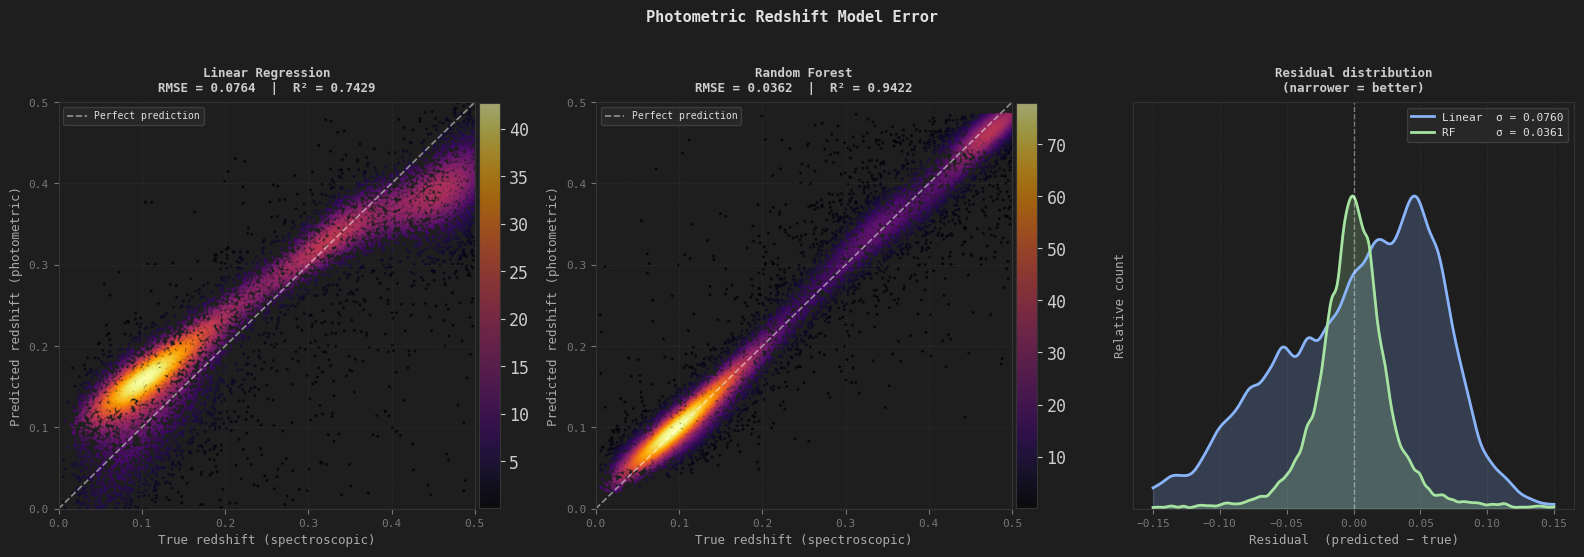

In [ ]:
# Setup the plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5), facecolor="#1e1e1e")
fig.suptitle("Photometric Redshift Model Error", color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

n_plot = min(10000, len(ypz_te)) # Set the number of points that we will plot to 10,000
rng = np.random.RandomState(67)
idx_p = rng.choice(len(ypz_te), n_plot, replace=False) # Randomly select indices for the points to plot from the test set

# Setup the data
yt_p = ypz_te.values[idx_p] # Select the true redshift values for these points
ylr_p = ypz_pred_lr[idx_p] # Select the predicted redshift values from the linear regression model for the points
yrf_p = ypz_pred_rf[idx_p] # Select the predicted redshift values from the random forest model for the points

# Left and middle plots: predicted vs true redshift for both models
for ax, y_pred, title, rmse, r2 in [(axes[0], ylr_p, "Linear Regression", lr_rmse, lr_r2), (axes[1], yrf_p, "Random Forest", rf_rmse, rf_r2)]:
    ax.set_facecolor("#1e1e1e") # Set the background color of the plot
    dens = gaussian_kde(np.vstack([yt_p, y_pred]))(np.vstack([yt_p, y_pred])) # Calculate the density of points in the predicted vs true redshift space using Gaussian KDE
    sidx = dens.argsort() # Get the indices that would sort the density values (for better visualization of dense regions)

    sc = ax.scatter(yt_p[sidx], y_pred[sidx], c=dens[sidx], cmap="inferno", s=1.5, alpha=0.6, rasterized=True) # Create the scatter plot

    plt.colorbar(sc, ax=ax, pad=0.01, fraction=0.046).outline.set_edgecolor("#333333") # Create a colourbar for density of points

    # Final plot formatting
    lims = [0, 0.50]
    ax.plot(lims, lims, "--", color="#ffffff", lw=1.2, alpha=0.5, label="Perfect prediction")
    ax.set_xlim(lims); ax.set_ylim(lims)
    ax.set_xlabel("True redshift (spectroscopic)", color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Predicted redshift (photometric)", color="#aaaaaa", fontsize=9)
    ax.set_title(f"{title}\nRMSE = {rmse:.4f}  |  R² = {r2:.4f}", color="#cccccc", fontsize=9, pad=8)
    ax.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=7)
    ax.tick_params(colors="#777777", labelsize=8)
    ax.grid(True, ls=":", alpha=0.08, color="#ffffff")
    for sp in ax.spines.values():
        sp.set_edgecolor("#333333")

# Right plot: residual distribution

ax3 = axes[2]; ax3.set_facecolor("#1e1e1e") # Set the background color of the plot

res_lr = ylr_p - yt_p # Calculate the residuals for the linear regression
res_rf = yrf_p - yt_p # Calculate the residuals for the random forest
x_res  = np.linspace(-0.15, 0.15, 400)

for res, color, label in [(res_lr, "#89b4fa", f"Linear  σ = {res_lr.std():.4f}"), (res_rf, "#a6e3a1", f"RF      σ = {res_rf.std():.4f}")]:
    kde = gaussian_kde(res, bw_method=0.06) # Calculate the kde of the residuals
    k = kde(x_res); k /= k.max() # Normalise the kde values
    ax3.fill_between(x_res, 0, k, color=color, alpha=0.22) # Fill the area under the curve
    ax3.plot(x_res, k, lw=2, color=color, label=label) # Plot the kde curve

# Final plot formatting
ax3.axvline(0, color="#ffffff", lw=1, ls="--", alpha=0.4)
ax3.set_xlabel("Residual", color="#aaaaaa", fontsize=9)
ax3.set_ylabel("Relative count", color="#aaaaaa", fontsize=9)
ax3.set_title("Residual distribution\n(narrower = better)", color="#cccccc", fontsize=9, pad=8)
ax3.set_yticks([]); ax3.set_ylim(0, 1.3)
ax3.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=8)
ax3.tick_params(colors="#777777", labelsize=8)
ax3.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax3.spines.values():
    sp.set_edgecolor("#333333")

# Display the plots
plt.tight_layout()
plt.show()

<div style="width: 1200px">

**Left panel (Linear Regression):** On the leftmost plot, which represents the linear regression algorithm, we can see that points do tend to cluster along the main diagonal, but with significant scatter. This is particularly noticable at very low and very high redshifts where the colour-redshift relationship becomes more complex. So, linear regression is fundamentally too simple for this problem.

**Middle panel (Random Forest):** The scatter on the middle plot (which represents the random forest algorithm) is significantly reduced. Here, the points cluster far more tightly along the perfect-prediction line, and the model performs much better across the full redshift range.

**Right panel (Residuals):** On the right plot, we created a residual distribution graph for the two algorithms. Here, we can see that the random forest's curve is noticeably narrower, meaning that the typical error ($\sigma$) is smaller. There are of course still outliers, but they probably correspond to physically unusual galaxies with strong emission lines that shift colours unexpectedly.

<br>

The next thing that we should plot is something called **feature importance**, which means *how much each input contributed to to the final answer*. For example, if asked to identify whether an object is a laptop or an ipad, you'll probably focus on whether the object has a keyboard or not much more than the object's colour.
</div>

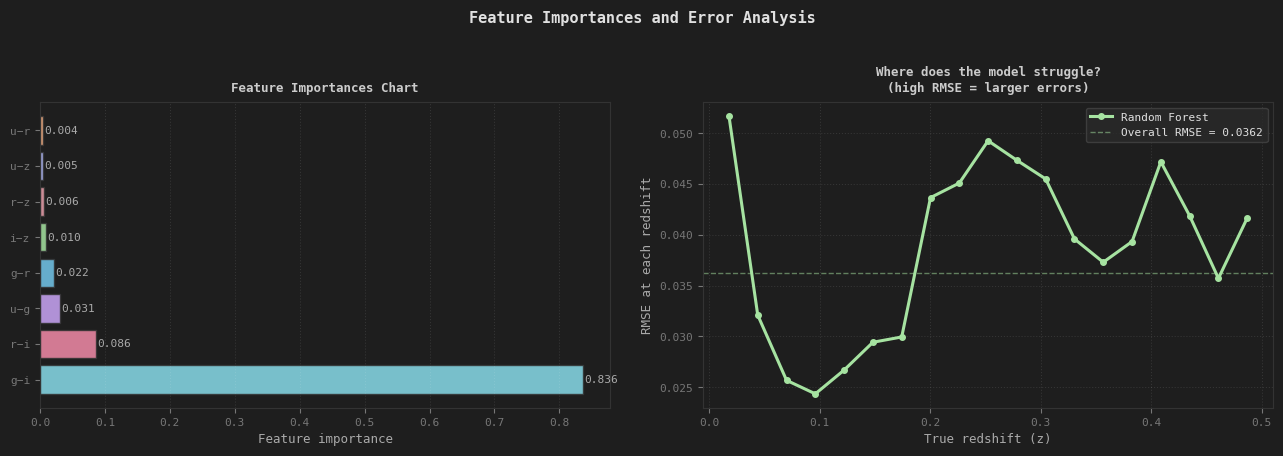

In [42]:
# Feature importances from the Random Forest
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor="#1e1e1e")
fig.suptitle("Feature Importances and Error Analysis", color="#e0e0e0", fontsize=11, fontweight="bold", y=1.01)

# Left plot: feature importances

ax1 = axes[0]; ax1.set_facecolor("#1e1e1e") # Set the background color of the plot
importances = rf_pz.feature_importances_ # Get the feature importances from the trained random forest model
feat_labels = ["u−g", "g−r", "r−i", "i−z", "u−r", "g−i", "r−z", "u−z"] # Define the labels for the features
sort_idx = np.argsort(importances)[::-1] # Get the indices that would sort the feature importances in descending order
colors_fi = ["#cba6f7","#74c7ec","#f38ba8","#a6e3a1","#fab387","#89dceb","#eba0ac","#b4befe","#f9e2af","#94e2d5"] # Define the colours to use

# Plot the feature importances as a horizontal bar chart
bars = ax1.barh([feat_labels[i] for i in sort_idx], importances[sort_idx], color=[colors_fi[i] for i in sort_idx], alpha=0.85, edgecolor="#333333")

# Annotate the bars with the importance values
for bar, val in zip(bars, importances[sort_idx]):
    ax1.text(val + 0.002, bar.get_y() + bar.get_height()/2, f"{val:.3f}", va="center", color="#aaaaaa", fontsize=8)

# Final plot formatting
ax1.set_xlabel("Feature importance", color="#aaaaaa", fontsize=9)
ax1.set_title("Feature Importances Chart", color="#cccccc", fontsize=9, pad=8)
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.10, color="#ffffff", axis="x")
for sp in ax1.spines.values():
    sp.set_edgecolor("#333333")

# Right plot: error as a function of true redshift

ax2 = axes[1]; ax2.set_facecolor("#1e1e1e") # Set the background color of the plot
z_bins = np.linspace(0.005, 0.50, 20) # Define bins in true redshift to calculate the RMSE in each bin (to see where the model struggles the most)
z_mids = 0.5*(z_bins[:-1]+z_bins[1:]) # Calculate the mid-point of each redshift bin for plotting
rmse_by_z = []
for lo, hi in zip(z_bins[:-1], z_bins[1:]): # Loop through each redshift bin and calculate the RMSE for the predictions in that bin
    mask = (ypz_te.values >= lo) & (ypz_te.values < hi)
    if mask.sum() < 20:
        rmse_by_z.append(np.nan)
    else:
        rmse_by_z.append(
            np.sqrt(mean_squared_error(ypz_te.values[mask], ypz_pred_rf[mask])))

# Plot the RMSE
ax2.plot(z_mids, rmse_by_z, color="#a6e3a1", lw=2.2, marker="o", markersize=4, label="Random Forest")

# Final plot formatting
ax2.axhline(rf_rmse, color="#a6e3a1", lw=1, ls="--", alpha=0.5, label=f"Overall RMSE = {rf_rmse:.4f}")
ax2.set_xlabel("True redshift (z)", color="#aaaaaa", fontsize=9)
ax2.set_ylabel("RMSE at each redshift", color="#aaaaaa", fontsize=9)
ax2.set_title("Where does the model struggle?\n(high RMSE = larger errors)", color="#cccccc", fontsize=9, pad=8)
ax2.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=8)
ax2.tick_params(colors="#777777", labelsize=8)
ax2.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax2.spines.values():
    sp.set_edgecolor("#333333")

# Display the plots
plt.tight_layout()
plt.show()

<div style="width: 1200px">

**[LEFT] Feature importances:** Woah!! The `g-i` index clearly dominates by a huge amount, with `r−i` at a distant second and everything else contributing very little. This actually makes pretty good physical sense. The `g−i` index spans most of the main spectral lines that a galaxy might have, like the hydrogen, oxygen and nitrogen emission lines, without extending so far that it picks up unhelpful noise from ultraviolet or mid-infrared. This means that it can capture the largest shift in the spectral energy distribution as redshift increases. The narrower indices like `u−g` or `i−z` each cover a relaively smaller slice of the spectrum and therefore pick up a weaker version of the same signal. On the other hand, the indices like `u-r` and `u-z` cover an unhelpfully large slice of the spectrum, and pay too much attention to the not useful ultraviolet emission.

<br>

**[RIGHT] RMSE by redshift:** On the right chart, we can see that our model's errors are not uniform across redshift. There's massive error at the smallest redshift values where there's not much data, but that quickly drops to a minimum at about 0.1. At this stage, the model is able to be trained heaps due to the abundance of training examples. However, the error starts to rise agian at higher $z$ where the sample is sparser and the Malmquist bias means only unusual, bright galaxies are detected.

</div>

<div style="width: 1200px">
<center>
<img src="images/ngc4388.jpg" width="500px"></img>

<i>Credit: Wikipedia</i>
</center>
</div>

<div style="width: 1200px">

Awesome! Now we could go on much much deeper into the rabbit hole of trying to find even better methods of photometric redshift, but I think that we ought to move to our next problem which is arguably more important to do, since it leads directly into answering our central question.

</div>

---

## Task 2 — Positioning Galaxies in Their Evolutionary Lifecycle

---

---

### Step 1: Setting the problem

---

<div style="width: 1200px">

Okay, so the photo-z task was supervised (we told the model what to predict). Now, let's see if we can get the computer to do something a bit more complex and exciting: positioning a galaxy in it's evolutionary lifecycle:

<br>

<center>
<span style="
border: 2px solid #DDDDDD;
padding: 15px;
font-size: 20px;
font-style: italic;">
"If we had no prior knowledge about galaxy types, what structure would the computer find in the data on its own?"</span>
</center>

<br>

This matters quite a bit for our central question. Throughout this project, we've only *imposed* structure, like dividing galaxies into the Blue Cloud, Green Valley, and Red Sequence using a threshold on g-r that we chose. But what if we just let the data speak for itself? What groups does the galaxy population naturally fall into, and do they correspond to what we expect from the physics?

<br>

Same as last time, let's start by choosing our features:

| Feature | Why it was chosen |
|---------|-------------|
| `u-g`, `g-r`, `r-i`, `i-z`, `g-i` | These are the most important colour indices which trace star formation across different spectral ranges. (We just saw this in the previous ML example with the random forest algorithm) |
| `C` | The concentration index is a morphological proxy for disc vs bulge, which changes over a galaxy's lifetime |
| `fracDeV_r`, `expAB_r` | The axis ratios and profile shapes are independent and complementary morphological measurements which could help the model focus on the galaxy's structure |
| `petroR50_r` | The half-light radius represents the physical extent of the stellar distribution, which also changes over a galaxy's lifetime |

Putting this into code:

In [43]:
LIFE_FEATS = ["u_g", "g_r", "r_i", "i_z", "g_i", "C", "fracDeV_r", "petroR50_r", "expAB_r"] # Define the features to use
LIFE_NAMES = ["u−g", "g−r", "r−i", "i−z", "g−i", "Concentration C", "fracDeV_r", "Half-light radius", "Axis ratio"] # Define the names for the features

gal_life = galaxies[(galaxies["redshift"] < 0.20) & (galaxies["expAB_r"] > 0)].copy() # Select galaxies with reliable measurements
X_life = gal_life[LIFE_FEATS].dropna() # Select the input features and drop any rows with missing values
gal_life = gal_life.loc[X_life.index].copy() # Keep only the galaxies with valid features

---

### Step 2: Principal Component Analysis

---

<div style="
display: inline-block;
width: 820px;
margin-right: 100px">

The next thing we need to do is let the computer find some aspects of galaxies that vary quite a bit. If, for example, almost all galaxies were roughly the same size (which they aren't), then it would be pretty hard for a computer to position galaxies in their lifecycle based on size alone. This is why we need **principal component analysis**.

**Principal Component Analysis** or **PCA** for short, finds the directions in **feature space* along which the data varies most. This essentially means that it finds *the most informative directions in a high-dimensional dataset*. Imagine you have measured 8 properties of each galaxy and want to visualise the data. It would obviously be very hard to plot 8 features, since we don't live in 8 dimensions. But what PCA allows us to do is basically summarise each galaxy with just 2 or 3 numbers, where those numbers preserve a lot of information about the original galaxy.

PCA is a type of **dimensionality reduction** technique, where, as you might expect, multiple dimensions are squished into 1 without losing too much information. There are other types of dimensionality reduction techniques, but PCA is the most widely used, and it's also the simplest.

</div>

<div style="
display: inline-block;
width: 280px">
<img src="images/pca.png"></img>
<center><i>Credit: Wikipedia</i></center>
</div>

<div style="width: 1200px">

**You can think of feature space as some big area or space, where each axis represents 1 feature of a galaxy.*

<br>

Let's incorporate PCA into our unsupervised model!

</div>

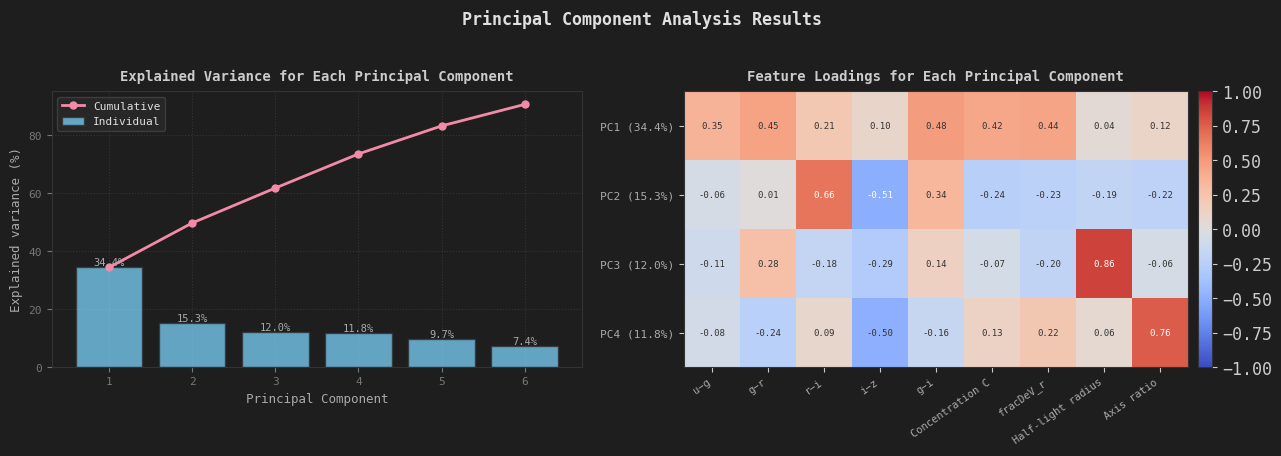

In [44]:
scaler_life = StandardScaler() # Initialise a standard scaler to normalise the features
X_life_s = scaler_life.fit_transform(X_life) # Fit the PCA on the normalised features and transform the data to the PCA space

# Perform PCA to reduce the dimensionality of the data and find the main directions of variation
pca = PCA(n_components=6, random_state=67)
X_pca = pca.fit_transform(X_life_s)
evr = pca.explained_variance_ratio_


# PLOTTING THE PCA RESULTS

# Setup the plot
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), facecolor="#1e1e1e")
fig.suptitle("Principal Component Analysis Results", color="#e0e0e0", fontsize=12, fontweight="bold", y=1.01)

# Left Plot: Explained Variance
ax1 = axes[0]
ax1.set_facecolor("#1e1e1e")

cumevr = np.cumsum(evr) # Calculate the cumulative explained variance
ax1.bar(range(1, len(evr)+1), evr*100, color="#74c7ec", alpha=0.8, edgecolor="#333333", label="Individual") # Plot the individual explained variance as a bar chart
ax1.plot(range(1, len(evr)+1), cumevr*100, color="#f38ba8", lw=2, marker="o", markersize=5, label="Cumulative") # Plot the cumulative explained variance as a line plot

# Add explained variance percentages to the bars individually
for i, (e, c) in enumerate(zip(evr, cumevr)):
    ax1.text(i+1, e*100+0.5, f"{e*100:.1f}%", ha="center", color="#aaaaaa", fontsize=7.5)

# Final plot formatting
ax1.set_xlabel("Principal Component", color="#aaaaaa", fontsize=9)
ax1.set_ylabel("Explained variance (%)", color="#aaaaaa", fontsize=9)
ax1.set_title("Explained Variance for Each Principal Component", color="#cccccc", fontsize=10, pad=8)
ax1.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=8)
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.10, color="#ffffff")
for sp in ax1.spines.values():
    sp.set_edgecolor("#333333")

# Right Plot: Loadings Heatmap
ax2 = axes[1]; ax2.set_facecolor("#1e1e1e")
loadings = pca.components_[:4]

im = ax2.imshow(loadings, cmap="coolwarm", vmin=-1, vmax=1, aspect="auto") # Plot the loadings as a heatmap for the first 4 principal components

# Set the ticks and labels
ax2.set_xticks(range(len(LIFE_NAMES)))
ax2.set_xticklabels(LIFE_NAMES, rotation=35, ha="right", color="#aaaaaa", fontsize=7.5)
ax2.set_yticks(range(4))
ax2.set_yticklabels([f"PC{i+1} ({evr[i]*100:.1f}%)" for i in range(4)], color="#aaaaaa", fontsize=8)
ax2.set_title("Feature Loadings for Each Principal Component", color="#cccccc", fontsize=10, pad=8)
for i in range(4):
    for j in range(len(LIFE_NAMES)):
        ax2.text(j, i, f"{loadings[i,j]:.2f}", ha="center", va="center", fontsize=6.5, color="white" if abs(loadings[i,j]) > 0.5 else "#333333")

# Create a colourbar
plt.colorbar(im, ax=ax2, fraction=0.03, pad=0.02).outline.set_edgecolor("#333333")
for sp in ax2.spines.values():
    sp.set_edgecolor("#333333")

plt.tight_layout()
plt.show()

<div style="width: 1200px">

**Left panel:** The first four principal components together capture the large majority of the variance in galaxy properties. Despite measuring 8 different properties, most of the interesting variation collapses into just a few numbers. This tells us that the galaxy population that we're looking at is much less diverse than an 8-dimensional description might suggest.

**Right panel (loadings):** Here, the loadings tell us which features of galaxies each principal component actually measures:

* **PC1** and **PC2** depend very heavily on the colour indices (`u_g`, `g_r`, `r_i`, `i_z`, `g_i`) as well as `fracDeV_r`. We'll call this the **colour-morphology evolutionary axis**, since galaxies with high PC1 are red and bulge-dominated, while galaxies with low PC1 are blue and disc-dominated. Interestingly, PC2 also looked at colours, but payed a lot more attention to the infrared colour indices, specifically, `r-i`, `i-z` and `g-i`. But this is actually so cool: the computer found almost the exact same main axis that astronomers identified from physical reasoning!

* **PC3** and **PC4** on the other hand, pick up variation in mostly `petroR50_r` (size) and `expAB_r` (axis ratio). We'll call this the **structural axis** because it's able to capture the diversity in physical extent and inclination at any given colour.

<br>

Let's visualise these axes against eachother:

</div>

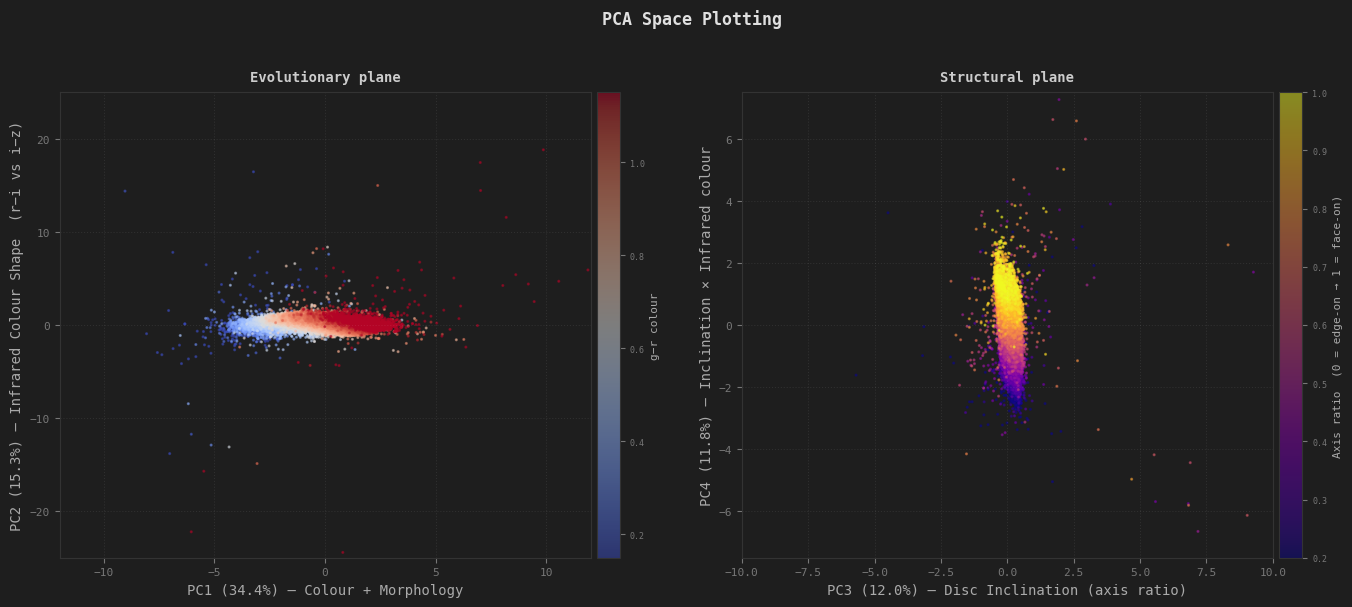

In [45]:
# Choose a 20,000-galaxy random sample
sample_idx = np.random.RandomState(67).choice(len(X_pca), min(20000, len(X_pca)), replace=False)

# Setup the plot
fig, axes = plt.subplots(1, 2, figsize=(14, 6), facecolor="#1e1e1e")
fig.suptitle("PCA Space Plotting", color="#e0e0e0", fontsize=12, fontweight="bold", y=1.01)

pc1 = X_pca[sample_idx, 0] # Get the values for PC1
pc2 = X_pca[sample_idx, 1] # Get the values for PC2
pc3 = X_pca[sample_idx, 2] # Get the values for PC3
pc4 = X_pca[sample_idx, 3] # Get the values for PC4

# Left Plot: PC1 vs PC2
ax1 = axes[0]; ax1.set_facecolor("#1e1e1e")
c1 = gal_life["g_r"].values[sample_idx] # g-r colour index
idx_s = np.argsort(c1)

# Create a scatter plot of PC1 vs PC2, coloured by the g-r colour index 
sc1 = ax1.scatter(pc1[idx_s], pc2[idx_s], c=c1[idx_s], cmap="coolwarm", vmin=0.15, vmax=1.15, s=1.5, alpha=0.5, rasterized=True)

# Add a colourbar for the g-r colour index
cb1 = plt.colorbar(sc1, ax=ax1, pad=0.01)
cb1.set_label("g−r colour", color="#aaaaaa", fontsize=8)
cb1.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cb1.ax.yaxis.get_ticklabels(), color="#777777", fontsize=6)
cb1.outline.set_edgecolor("#333333")

# Final plot formatting
ax1.set_xlabel(f"PC1 ({evr[0]*100:.1f}%) — Colour + Morphology", color="#aaaaaa", fontsize=10)
ax1.set_ylabel(f"PC2 ({evr[1]*100:.1f}%) — Infrared Colour Shape  (r−i vs i−z)", color="#aaaaaa", fontsize=10)
ax1.set_title("Evolutionary plane", color="#cccccc", fontsize=10, pad=8)
ax1.tick_params(colors="#777777", labelsize=8)
ax1.grid(True, ls=":", alpha=0.08, color="#ffffff")
ax1.set_xlim(-12, 12)
ax1.set_ylim(-25, 25)
for sp in ax1.spines.values():
    sp.set_edgecolor("#333333")

# Right Plot: PC3 vs PC4
ax2 = axes[1]; ax2.set_facecolor("#1e1e1e")
c2 = gal_life["expAB_r"].values[sample_idx] # axis ratio
idx_s2 = np.argsort(c2)

# Create a scatter plot of PC3 vs PC4, coloured by the axis ratio
sc2 = ax2.scatter(pc3[idx_s2], pc4[idx_s2], c=c2[idx_s2], cmap="plasma", vmin=0.2, vmax=1.0, s=1.5, alpha=0.5, rasterized=True)

# Add a colourbar for the axis ratio
cb2 = plt.colorbar(sc2, ax=ax2, pad=0.01)
cb2.set_label("Axis ratio  (0 = edge-on → 1 = face-on)", color="#aaaaaa", fontsize=8)
cb2.ax.yaxis.set_tick_params(color="#777777")
plt.setp(cb2.ax.yaxis.get_ticklabels(), color="#777777", fontsize=6)
cb2.outline.set_edgecolor("#333333")

# Final plot formatting
ax2.set_xlabel(f"PC3 ({evr[2]*100:.1f}%) — Disc Inclination (axis ratio)", color="#aaaaaa", fontsize=10)
ax2.set_ylabel(f"PC4 ({evr[3]*100:.1f}%) — Inclination × Infrared colour", color="#aaaaaa", fontsize=10)
ax2.set_title("Structural plane", color="#cccccc", fontsize=10, pad=8)
ax2.tick_params(colors="#777777", labelsize=8)
ax2.grid(True, ls=":", alpha=0.08, color="#ffffff")
ax2.set_xlim(-10, 10)
ax2.set_ylim(-7.5, 7.5)
for sp in ax2.spines.values():
    sp.set_edgecolor("#333333")

# Display the plots
plt.tight_layout()
plt.show()

<div style="width: 1200px">

Okay let's analyse what each plot tells us:

**[LEFT PLOT] The Evolutionary Plane (PC1 vs PC2):**

The first thing that we can notice is that the smooth colour gradient running along PC1 confirms that it's an evolutionary colour axis, where blue star-forming galaxies are on the left, and red quenched ellipticals are on the right. However, the more interesting but subtle finding is in PC2. Because it's primarily influenced by the infrared colour indices, it sort of encodes something about the *shape* of the infrared spectral slope, contrasting `r−i` (positive loading) against `i−z` (negative loading). If you saw on the previous set of plots, PC2 was very red an varied very positively with `r-i`, whereas it was deep blue and varied very negatively with `i-z`. This tells us that there's actually some variation in the stellar populations of galaxies at the same overall colour, because dust-reddened star-forming galaxies and actually old stellar populations can have similar g−r but different infrared slopes. And it looks like PC2 might be able to distinguish between them! Amazing!

<br>

**[RIGHT PLOT] The Structural Plane (PC3 vs PC4):**

On the right, we can definitely see that PC4 is overwhelmingly dominated by the galaxy's axis ratio or elongation (which is what we saw previously). But interestingly, this encodes nothing about evolution, but rather **viewing geometry**. A disc galaxy seen face-on appears round (so it has an axis ratio of about 1), however the exact same galaxy seen edge-on appears more elongated (the axis ratio would be closer to 0). The fact that PCA isolates this into its own separate plane completely separate from the evolutionary axes is reassuring, because it means that the evolutionary signal of PC1 and PC2 is not being contaminated by the random orientations of disc galaxies in space. In this sense, PC3 and PC4 are less useful for actually figuring out where a galaxy is in it's lifecyle, but they can help a lot in making sure that evolutionary signals are completely isolated.

</div>

---

### Step 2: K-Means Clustering

---

<div style="
display: inline-block;
width: 800px;
margin-right: 70px">

Alright! Step 2 is complete and we have our principal components! Now we need to use those PC axes to divide up our dataset into groups using **K-means clustering**.

Formally, **K-Means clustering** divides the data into $k$ groups by finding cluster centres that minimise the average distance from each point to its nearest centre. Then, the algorithm iterates until the assignments stabilise, and no galaxy changes which cluster it belongs to. This all sounds very fancy, but all it means is it tries to find some cluster centres that are positioned so that average distance from any point to the cluster centre is as small as possible. Then, each point gets assigned to the cluster which it is closest to.

You can think of all the points as people's homes. What we want to do is place down $k$ hospitals in the area. Obviously, everyone wants their home to be near a hospital, so we have to position the hospitals in the way so that **everyone** is close to a hospital. Then, we go to each house and tell the people something like, "your nearest hospital is the Isaac hospital". These people now belong the Isaac hospital group.

For our purposes, we'll use $k=5$, since we have 5 main "clusters": Active Spirals, Transition Spirals, Green Valley Galaxies, Passive Discs, and Ellipticals.

<br>

</div>

<div style="
display: inline-block;
width: 330px">
<img src="images/kmeans.gif"></img>
<center><i>Credit: Amazon Web Services</i></center>
</div>

Let's put this into code!

In [46]:
X_clust = X_pca[:, :4] # Use the first 4 PCs

# Clean the PCA space before clustering
bounds = {}
for i in range(4): # For each of the first 4 principal components, calculate the 0.5th and 99.5th percentiles to define bounds for outlier removal
    lo, hi = np.percentile(X_pca[:, i], [0.5, 99.5])
    bounds[i] = (lo, hi)    

# Keep only galaxies within bounds on all 4 components
in_bounds_mask = np.ones(len(X_pca), dtype=bool)
for i, (lo, hi) in bounds.items(): # Update the mask to keep only galaxies that are within the defined bounds for each principal component
    in_bounds_mask &= (X_pca[:, i] >= lo) & (X_pca[:, i] <= hi)

# Cluster on the cleaned PCA space
X_clust = X_pca[in_bounds_mask, :4]
gal_life_clust = gal_life.iloc[in_bounds_mask].copy()

# Print the number of galaxies that will be used for clustering after removing outliers
print(f"Galaxies used for clustering: {X_clust.shape[0]:,} ({in_bounds_mask.mean()*100:.1f}% of sample)")

# Fit the KMeans model and assign cluster labels to the galaxies
km_final = KMeans(n_clusters=5, random_state=67, n_init=20)
cluster_labels = km_final.fit_predict(X_clust) # Fit the KMeans model to the cleaned PCA data and get the cluster labels for each galaxy
gal_life_clust["cluster"] = cluster_labels # Add the cluster labels to the dataframe

# Calculate and print the properties of each cluster
props = gal_life_clust.groupby("cluster").agg(g_r=("g_r","median"), C=("C","median"), fracDeV_r=("fracDeV_r","median"), n=("g_r","count")).round(3)
print("\nCluster properties:\n", props)

# Name by rank order of g_r median
g_r_medians  = gal_life_clust.groupby("cluster")["g_r"].median().sort_values()
ordered_names = ["Active Spirals", "Transition Spirals", "Green Valley", "Passive Discs", "Ellipticals"]

# Define cluster names and colours for plotting
CLUSTER_NAMES = {cid: name for cid, name in zip(g_r_medians.index, ordered_names)}
CLUSTER_COLOURS = {
    "Active Spirals": "#74c7ec",
    "Transition Spirals": "#89dceb",
    "Green Valley": "#69db7c",
    "Passive Discs": "#fab387",
    "Ellipticals": "#f38ba8"
}
gal_life_clust["cluster_name"] = gal_life_clust["cluster"].map(CLUSTER_NAMES)

# Replace gal_life for stuff below
gal_life_original = gal_life.copy() # Keep a copy of the original gal_life
gal_life = gal_life_clust.copy()

# Print the cluster names
print("\nNames:", CLUSTER_NAMES)

Galaxies used for clustering: 91,411 (97.6% of sample)

Cluster properties:
            g_r      C  fracDeV_r      n
cluster                                
0        1.011  2.200      0.873  17624
1        1.057  2.422      1.000  28668
2        0.525  1.746      0.179  15665
3        0.838  2.110      0.876  15748
4        0.813  1.883      0.266  13706

Names: {2: 'Active Spirals', 4: 'Transition Spirals', 3: 'Green Valley', 0: 'Passive Discs', 1: 'Ellipticals'}


Okay great! We've clustered our data into the 5 main galaxy types, so now let's plot it!

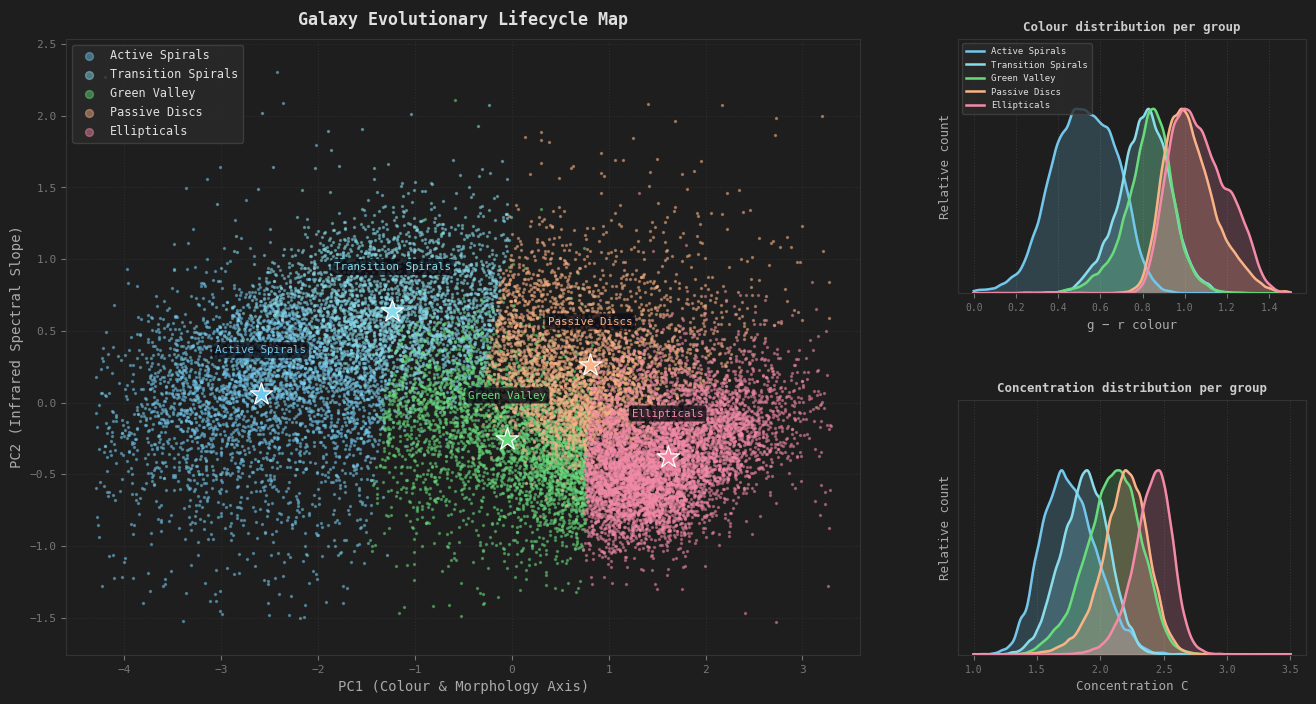

In [47]:
pc1_all = X_pca[in_bounds_mask, 0] # Get PC1 for galaxies that are within the defined bounds
pc2_all = X_pca[in_bounds_mask, 1] # Get PC2 for galaxies that are within the defined bounds 

# Choose a random sample of 20,000 galaxies
sp = np.random.RandomState(67).choice(len(pc1_all), min(20000, len(pc1_all)), replace=False)
pc1 = pc1_all[sp] # Get the PC1 values for the random sample of galaxies
pc2 = pc2_all[sp] # Get the PC2 values for the random sample of galaxies
cnames = gal_life["cluster_name"].values[sp] # Get the cluster names for the random sample of galaxies

# Axis limits from data
p1_lo, p1_hi = pc1.min(), pc1.max() # Get the minimum and maximum values of PC1 to define the axis limits
p2_lo, p2_hi = pc2.min(), pc2.max() # Get the minimum and maximum values of PC2 to define the axis limits

# Add some padding to the axis limits for better visualisation
p1_pad = (p1_hi - p1_lo) * 0.04
p2_pad = (p2_hi - p2_lo) * 0.06

# Calculate the cluster centres
centres_2d = {cname: (pc1[cnames == cname].mean(), pc2[cnames == cname].mean()) for cname in CLUSTER_NAMES.values() if (cnames == cname).any()}

# Setup the plot
fig = plt.figure(figsize=(16, 8), facecolor="#1e1e1e")
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.28)
ax_main = fig.add_subplot(gs[:, :2])
ax_gr = fig.add_subplot(gs[0, 2])
ax_c  = fig.add_subplot(gs[1, 2])
for ax in [ax_main, ax_gr, ax_c]:
    ax.set_facecolor("#1e1e1e") # Set the background color for all subplots

# MAIN SCATTER PLOT
for cname in ordered_names:
    color = CLUSTER_COLOURS[cname] # Get the colour for the current cluster name
    mask  = cnames == cname # Create a boolean mask to select the galaxies that belong to the current cluster
    if not mask.any(): continue # If there are no galaxies in this cluster, skip to the next iteration
    ax_main.scatter(pc1[mask], pc2[mask], color=color, s=2, alpha=0.45, label=cname, rasterized=True)

# Plot the cluster centres and annotate them with their names
for cname, (cx, cy) in centres_2d.items():
    color = CLUSTER_COLOURS[cname]
    ax_main.scatter(cx, cy, s=280, color=color, marker="*", edgecolors="white", linewidths=0.9, zorder=8) # Plot the cluster centres as stars
    y_offset = (p2_hi - p2_lo) * 0.07
    ax_main.text(cx, cy + y_offset, cname, color=color, fontsize=7.8, ha="center", va="bottom", bbox=dict(boxstyle="round, pad=0.28", fc="#0d0d14", ec="none", alpha=0.80))

# Final plot formatting
ax_main.set_xlim(p1_lo - p1_pad, p1_hi + p1_pad)
ax_main.set_ylim(p2_lo - p2_pad, p2_hi + p2_pad)
ax_main.set_xlabel("PC1 (Colour & Morphology Axis)", color="#aaaaaa", fontsize=10)
ax_main.set_ylabel("PC2 (Infrared Spectral Slope)", color="#aaaaaa", fontsize=10)
ax_main.set_title("Galaxy Evolutionary Lifecycle Map", color="#e0e0e0", fontsize=12, pad=10)
ax_main.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=8.5, markerscale=4)
ax_main.tick_params(colors="#777777", labelsize=8)
ax_main.grid(True, ls=":", alpha=0.07, color="#ffffff")
for sp2 in ax_main.spines.values():
    sp2.set_edgecolor("#333333")

# SIDE KDE PLOTS
x_gr = np.linspace(0.0, 1.5, 400)
x_c  = np.linspace(1.0, 3.5, 400)

for cname in ordered_names: # Loop through each cluster and plot the KDEs
    color = CLUSTER_COLOURS[cname]
    sub = gal_life[gal_life["cluster_name"] == cname]
    if len(sub) < 50: continue # Skip clusters with not enough galaxies
    for ax, feat, xr in [(ax_gr, "g_r", x_gr), (ax_c, "C", x_c)]:
        v = sub[feat].dropna().values
        if len(v) < 30: continue
        kde = gaussian_kde(v, bw_method=0.10)
        k = kde(xr); k /= k.max() # Normalise the KDE values
        ax.fill_between(xr, 0, k, color=color, alpha=0.22) # Fill the area under the KDE curve
        ax.plot(xr, k, lw=1.8, color=color, label=cname) # Plot the KDE curve

# Final plot formatting for the side KDE plots
for ax, xlabel, title in [(ax_gr, "g − r colour", "Colour distribution per group"), (ax_c, "Concentration C", "Concentration distribution per group")]:
    ax.set_xlabel(xlabel, color="#aaaaaa", fontsize=9)
    ax.set_ylabel("Relative count", color="#aaaaaa", fontsize=9)
    ax.set_title(title, color="#cccccc", fontsize=9, pad=6)
    ax.set_yticks([])
    ax.set_ylim(0, 1.38)
    ax.tick_params(colors="#777777", labelsize=7)
    ax.grid(True, ls=":", alpha=0.10, color="#ffffff")
    for sp2 in ax.spines.values():
        sp2.set_edgecolor("#333333")

# Add legends to the side plots
ax_gr.legend(facecolor="#2a2a2a", edgecolor="#444444", labelcolor="#e0e0e0", fontsize=6.5, loc="upper left")

# Display the plots
plt.show()

<div style="width: 1200px">

Wow.

This is the central result of the notebook, and arguably of the entire project.

**The main panel** shows every galaxy (or at least a random subset of it) plotted in the 2D PCA space, coloured by the cluster the algorithm assigned it to. Without being told anything about galaxy types, quenching, or the Hubble sequence, the algorithm has independently discovered five groups that align really well with the physical picture built across the previous four notebooks:

* **Active Spirals (blue):** These hava a low PC1, meaning that they are blue, disc-dominated, and actively star-forming spirals
* **Transition Spirals (light blue):** These have slightly higher PC1 and PC2, so they are marginally redder, and possibly in early quenching
* **Green Valley (green):** This is the bridge between the two populations, and if you can see, this area has points which are sparser compared to say the elliptical group
* **Passive Discs (orange):** Passive discs are red but structurally disc-like. They are quenched lenticulars that retained their disc, and this is clearly shown in the plot
* **Ellipticals (pink):** The elliptical galaxies have the highest PC1 and lowest PC2, showing that they are fully quenched, bulge-dominated, and very red

**The side panels** confirm each group has distinct colour (top-right) and concentration (bottom-right) distributions. The progression from blue and more diffuse to red and more compact is exactly the stuff that we identified physically in previous sections.

I personally think that this is so awesome! Using some carefully chosen features and an unsupervised machine learning model, a computer was able to quickly identify goups of galaxies that were physically observed and differentiated by astronomers over decades.

</div>

---

### What We've Learned

---

<div style="width: 1200px">

This notebook demonstrated two distinct but complementary ways machine learning can advance galaxy science:

**1. Supervised regression (photo-z):** We learnt that:

* Galaxy colours encode redshift information
* Random Forests can extract this redshift information much better than a linear model
* Feature importances confirm that broad colour indices (`g_i` and `r_i`) carry the most useful information, because they're able to capture the tilt of the shifted spectral distribution
* The model's errors increase at high redshift, telling us that the flux limit restricted our training data, and taught us that ML models are only as good as the data they learn from

**2. Unsupervised discovery (PCA + K-Means):** We learnt that:

* PCA shows that our 8 main galaxy properties actually only collapse onto 2 meaningful axes: a colour-morphology evolutionary axis and a structural axis
* K-Means can independently discover the same evolutionary populations that astronomers have identified over decades: spirals, green valley galaxies, passive discs, and ellipticals

<br>

So I think the key thing to take away from this section is that **ML is the most powerful when it confirms what physics predicts, and the most valuable when it reveals what physics missed.**

In the next section, we'll look at all the stuff we've learnt and finally answer our original question :)

</div>